<a href="https://colab.research.google.com/github/Crnkcbs/money_fraud/blob/gmzbyzy/Mobile_Fraud_Analysis_Gamze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import auth
auth.authenticate_user()

In [2]:
pip install google-cloud-bigquery pandas pandas-gbq

In [7]:
import pandas as pd
from google.cloud import bigquery

# Tam tablo yolunu tanımlayın
full_table_path = 'data426-group3.dbt_gmzbyzy.mart_data426_group3__main_analysis'

# Tam tablo yolundan proje kimliğini ayıklayın
# Proje kimliği genellikle ilk bileşendir.
project_id = full_table_path.split('.')[0]

# BigQuery istemcisini (client) başlatın ve proje kimliğini belirtin
client = bigquery.Client(project=project_id)

# Çalıştırmak istediğiniz SQL sorgusu
# Sorguda doğrudan tam tablo yolunu kullanıyoruz.
query = f"""
    SELECT * FROM `{full_table_path}`
"""

# Sorguyu çalıştırın ve doğrudan Pandas DataFrame'e dönüştürün
df = client.query(query).to_dataframe()

# İlk birkaç satırı göster
print(df.head())

  transaction_id  step      type  type_code      amount amount_bucket  \
0   TX_005270759   372  TRANSFER          1   916889.17       500K-1M   
1   TX_005273771   372  TRANSFER          1  1405799.12           1M+   
2   TX_005273921   372  TRANSFER          1   206603.76     100K-500K   
3   TX_005281842   372  TRANSFER          1   155157.10     100K-500K   
4   TX_005283068   372  TRANSFER          1   552157.30       500K-1M   

   old_balance_orig  new_balance_orig  old_balance_dest  new_balance_dest  \
0          82770.00               0.0          34276.89         951166.06   
1          23122.00               0.0              0.00        1405799.12   
2           1272.15               0.0         460305.56         666909.32   
3              0.00               0.0         823957.14         979114.24   
4         680692.20          128534.9        7121056.15        7673213.44   

   is_fraud  is_flagged_fraud  is_merchant_dest  is_customer_dest  \
0         0                 0

# İşlem Tutarı (Miktar) ve Dolandırıcılık Analizi

Dolandırıcılık işlemlerinin işlem tutarı (amount) dağılımı normal işlemlerden farklı mı?

In [8]:
df['is_fraud'] = df['is_fraud'].astype(int)

# Log dönüşüm (çok önemli çünkü amount skewed)
import numpy as np
df['log_amount'] = np.log1p(df['amount'])

In [9]:
df.groupby('is_fraud')['amount'].agg(['mean','median','count'])

,mean,median,count
is_fraud,,,
0,1.781970e+05,74684.72,6354407
1,1.467967e+06,441423.44,8213


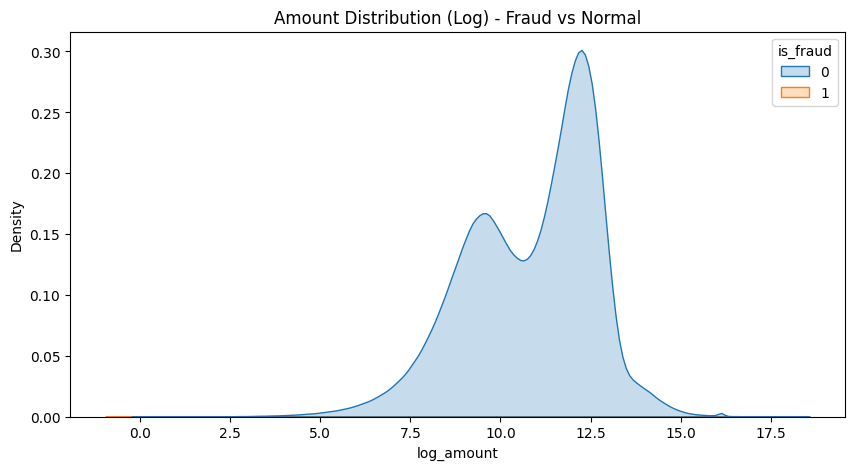

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.kdeplot(data=df, x='log_amount', hue='is_fraud', fill=True)
plt.title("Amount Distribution (Log) - Fraud vs Normal")
plt.show()